Saving panasonic_engineered_sample.xlsx to panasonic_engineered_sample (6).xlsx
Positive: r = 0.7284
Negative (Cycle 1 only): r = -0.9480
No correlation: r = -0.0110


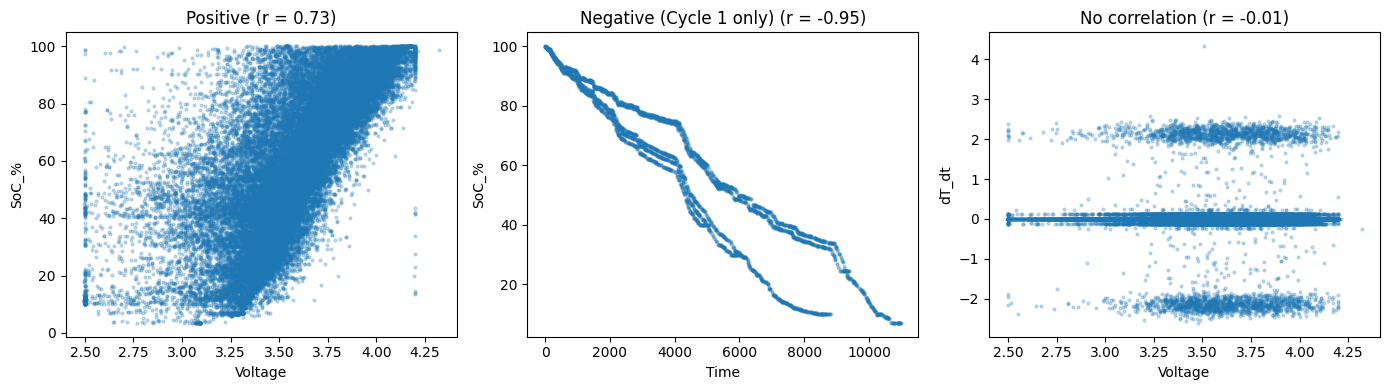

In [13]:
from google.colab import files
import math
import pandas as pd
import matplotlib.pyplot as plt

uploaded = files.upload()
df = pd.read_excel(list(uploaded.keys())[0])

def pearson(x, y):
    n = len(x)
    mx, my = sum(x) / n, sum(y) / n
    num = sum((a - mx) * (b - my) for a, b in zip(x, y))
    den = math.sqrt(sum((a - mx) ** 2 for a in x) * sum((b - my) ** 2 for b in y))
    return num / den

cycle = df[df["Cycle_Name"] == "Cycle_1_Pan18650PF"]

pairs = {
    "Positive": (df, "Voltage", "SoC_%"),
    "Negative (Cycle 1 only)": (cycle, "Time", "SoC_%"),
    "No correlation": (df, "Voltage", "dT_dt"),
}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, (data, cx, cy)) in zip(axes, pairs.items()):
    d = data[[cx, cy]].dropna()
    x, y = d[cx].tolist(), d[cy].tolist()
    r = pearson(x, y)
    print(f"{name}: r = {r:.4f}")
    ax.scatter(x, y, s=4, alpha=0.25)
    ax.set_title(f"{name} (r = {r:.2f})")
    ax.set_xlabel(cx)
    ax.set_ylabel(cy)
plt.tight_layout()
plt.show()